# CROMA STORE SALES ANALYSIS:--

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) IMPORT DATA 

In [2]:
Customers = pd.read_csv("D:/messy data/messy data/messy_customers.csv",encoding="latin-1")
Order_items = pd.read_csv("D:/messy data/messy data/messy_order_items.csv",encoding="latin-1")
Orders = pd.read_csv("D:/messy data/messy data/messy_orders.csv",encoding="latin-1")
Products= pd.read_csv("D:/messy data/messy data/messy_products.csv",encoding="latin-1")    

In [3]:
Customers

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


NOTE: The dataset contains 520 rows including customer_id, customer_name , city and signup date.

In [4]:
Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    520 non-null    object
 1   customer_name  492 non-null    object
 2   city           479 non-null    object
 3   signup_date    520 non-null    object
dtypes: object(4)
memory usage: 16.4+ KB


Note:- There are some null values in customer_name and city. A column with name signup_date which is not in proper format so we have to convert it into proper format.

In [5]:
Customers.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0033,Customer_218,Hyderabad,2023-06-15
freq,2,2,54,4


NOTE: This function shows the statistical summary of the numeric columns: customer_id, customer_name, city and signup_date. It provides measures such as count, unique, top and frequency values.

In [6]:
Customers[Customers.duplicated(keep=False)]

,customer_id,customer_name,city,signup_date
13,C0014,Customer_14,delhi,2024-08-18
32,C0033,Customer_33,mumbai,2024-04-30
132,C0133,Customer_133,Mumbai,2025-05-10
155,C0156,Customer_156,Pune,2024-08-07
179,C0180,Customer_180,NaN,2025-01-16
217,C0218,Customer_218,delhi,2025-02-02
221,C0222,Customer_222,Hyderabad,2024-05-20
249,C0250,Customer_250,Mumbai,2024-12-31
293,C0294,Customer_294,Hyderabad,2023-09-12
302,C0303,Customer_303,Kolkata,2024-03-23


NOTE: Deleted duplicate values from Customers table.

In [7]:
Order_items

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


Note: The dataset contains 2050 rows, including order_item_id, order_id, product_id, quantity, unit_price.

In [8]:
Order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   object 
 2   product_id     2050 non-null   object 
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.2+ KB


NOTE: In this table we have a column with name quantity which is not in proper format so we have to convert it into proper format and also we have null values in quantity and unit price column.

In [9]:
Order_items.describe()

,order_item_id,quantity,unit_price
count,2050.000000,1732.000000,1039.000000
mean,999.866341,1.991339,44956.006737
std,576.435038,1.411120,24978.977806
min,1.000000,0.000000,1072.000000
25%,502.250000,1.000000,23987.000000
50%,998.500000,2.000000,43654.000000
75%,1499.750000,3.000000,65136.500000
max,2000.000000,4.000000,89980.000000


NOTE: It shows statistical summary of the numeric columns: 'order_item_id','quantity','unit_price' It provides measures such as count,mean,standard deviation, minimum, quartiles(25%, 50%, 75%), and maximum values From the summary, we can observe the distribution of quantities and unit prices, and it also indicates that some values are missing in quantity and unit_price columns.

In [10]:
Order_items[Order_items.duplicated(keep=False)]

,order_item_id,order_id,product_id,quantity,unit_price
110,111,O01090,P018,0.0,41057.0
155,156,O00621,P020,1.0,NaN
158,159,O00727,P002,1.0,34931.0
196,197,O00301,P003,3.0,60818.0
275,276,O00571,P022,1.0,20373.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


NOTE: Deleted duplicate values from Order_items table.

In [11]:
Orders

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


NOTE: The dataset contains 1240 rows including order_id, customer_id , order_date and payment_method.

In [12]:
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        1240 non-null   object
 1   customer_id     1240 non-null   object
 2   order_date      1240 non-null   object
 3   payment_method  1095 non-null   object
dtypes: object(4)
memory usage: 38.9+ KB


NOTE: In orders table there is a column with name order_date which is not in proper format so i have to convert it into pandas date time format and also in column payment_method there is null values also found.

In [13]:
Orders.describe()

,order_id,customer_id,order_date,payment_method
count,1240,1240,1240,1095
unique,1200,448,815,7
top,O00313,C0218,02-03-2024,Credit Card
freq,2,10,5,171


NOTE: It shows statistical summary of the numeric columns: order_id, customer_id, order_date, payment_method. It provides measures such as count, unique, top and frequency values.

In [14]:
Orders[Orders.duplicated(keep=False)]

,order_id,customer_id,order_date,payment_method
14,O00015,C0329,02/09/2024,Cash on Delivery
71,O00072,C0033,2024-01-06,UPI
116,O00117,C0061,04-07-2025,UPI
127,O00128,C0383,03-31-2025,Credit Card
140,O00141,C0217,13/10/2024,Debit Card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


NOTE: Deleted duplicate values from Orders table.

In [15]:
Products

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


NOTE: The dataset contains 90 rows including product_id, product_name , category and base_price.

In [16]:
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     object 
 1   product_name  90 non-null     object 
 2   category      90 non-null     object 
 3   base_price    33 non-null     float64
dtypes: float64(1), object(3)
memory usage: 2.9+ KB


Note:- There are some null values in base_price

In [17]:
Products.describe()

,base_price
count,33.000000
mean,45047.454545
std,25654.215131
min,2571.000000
25%,27157.000000
50%,47453.000000
75%,68660.000000
max,84776.000000


NOTE: It shows statistical summary of the numeric column: base_price. It provides measures such as count, mean, standard deviation, minimum, quartiles(25%, 50%, 75%) and maximum values.

In [18]:
Products[Products.duplicated(keep=False)]

,product_id,product_name,category,base_price
9,P010,iPhone 13,smart phone,NaN
16,P017,Keyboard,Smartphone,NaN
19,P020,Dell Inspiron,Smartphone,NaN
21,P022,Samsung Tab,Accessory,NaN
32,P033,Wireless Mouse,laptop,47453.0
51,P052,Xiaomi Redmi,smart phone,NaN
58,P059,OnePlus,Accessories,NaN
61,P062,Dell Inspiron,Tablet,NaN
71,P072,Dell Inspiron,Tablet,NaN
75,P076,Wireless Mouse,Accessory,15249.0


NOTE: Deleted duplicate values from Product table.

# 2) Pre-Processing Data

In [19]:
Customers.drop_duplicates(inplace=True)

In [20]:
Orders.drop_duplicates(inplace=True)

In [21]:
Order_items.drop_duplicates(inplace=True)

In [22]:
Products.drop_duplicates(inplace=True)

NOTE: Duplicate values in tables are now deleted

In [23]:
Orders['order_date'] = pd.to_datetime(Orders['order_date'],format='mixed')

NOTE: order_date in orders table are in mixed format so we use format function.

In [24]:
Customers['signup_date'] = pd.to_datetime(Customers['signup_date'])

NOTE: Signup date column in customers table now in proper pandas date time format

# 3) Handling Inconsistant Data

In [25]:
Customers['city'] = Customers['city'].str.title()

NOTE: str is a module of pandas which operates string values and with the help title function first letter is capital and other are small.

In [26]:
Customers['city']=Customers['city'].replace({'Bangalore':'Bengaluru'}).copy()

NOTE: By using replace function we handle inconsistant values in city

In [27]:
Products['category']=Products['category'].str.title()
Products['category']=Products['category'].replace({"Accessory":"Accessories","Smart Phone":"Smartphone"})

NOTE: By using replace function we handle inconsistant values in category column

In [28]:
Orders['payment_method']=Orders['payment_method'].str.title()
Orders['payment_method']=Orders['payment_method'].replace({"Cash On Delivery":"Cash"})

NOTE: By using replace function we handle inconsistant values in payment_method column

# 4) Handling missing values

In [29]:
Customers.isnull().sum()

customer_id       0
customer_name    28
city             40
signup_date       0
dtype: int64

NOTE: There are 28 null values in customer_name and 40 null values in city.

In [30]:
Orders.isnull().sum()

order_id            0
customer_id         0
order_date          0
payment_method    141
dtype: int64

NOTE: There are 141 null values in payment_method.

In [31]:
Order_items.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         313
unit_price       990
dtype: int64

NOTE: There are 313 null values in quantity and 990 null values in unit_price.

In [32]:
Products.isnull().sum()

product_id       0
product_name     0
category         0
base_price      49
dtype: int64

Note: There are 49 null values in base_price.

In [33]:
Orders['payment_method']=Orders['payment_method'].ffill().copy()

NOTE: I fill payment method's null values by using forward fill function and we pass a copy of that column.

In [34]:
Customers['city']=Customers['city'].bfill().copy()

NOTE: I fill city's null values by using backward fill function and we pass a copy of that column.

In [35]:
Products.groupby('category')['base_price'].mean()

category
Accessories    44411.000000
Laptop         46918.750000
Smartphone     50188.888889
Tablet         40848.142857
Name: base_price, dtype: float64

In [36]:
Order_items['unit_price']=Order_items['unit_price'].fillna(Order_items['product_id'].map(Products.set_index('product_id')['base_price']))

NOTE: Fill missing values in unit_price are imputed by mapping each product_id to its corresponding base_price from the products dataset.

In [37]:
Order_items.fillna({'quantity':Order_items['quantity'].mean(),'unit_price':Order_items['unit_price'].mean()},inplace=True)

In [38]:
Order_items

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.000000,47453.000000
1,2,O00857,P010,1.000000,45038.245702
2,3,O00589,P007,2.000000,77415.000000
3,4,O00112,P045,2.000000,49066.000000
4,5,O00322,P036,2.000000,58380.000000
...,...,...,...,...,...
1995,1996,O00944,P007,4.000000,64106.000000
1996,1997,O00629,P017,4.000000,45038.245702
1997,1998,O00703,P008,0.000000,76524.000000
1998,1999,O01083,P043,3.000000,18251.000000


NOTE: Rest of the missing values in unit_price and quantity column are fill by using mean

In [39]:
Order_items['quantity']=Order_items['quantity'].astype('int')

NOTE: Convert datatype of quantity column to integer

# 5) Merging Data

In [40]:
first = Order_items.merge(Products,on='product_id',how ='outer')

In [41]:
second = Orders.merge(Customers,on='customer_id',how='outer')

In [42]:
df= first.merge(second,on='order_id',how='inner')

In [43]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Credit Card,Customer_168,Delhi,2023-07-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0,C0217,2024-03-27,Upi,Customer_217,Pune,2023-04-05
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20


NOTE: This is my final dataset where over all information according to all four table has been included.

# 6) Transform Data / Feature Engineering

In [44]:
df['Sales'] = df['quantity']*df['unit_price']

In [45]:
df['year'] = df['order_date'].dt.year

In [46]:
df['month'] = df['order_date'].dt.month_name()

In [47]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date,Sales,year,month
0,228,O00862,P001,1,30940.0,Lenovo IdeaPad,Tablet,28151.0,C0246,2024-09-24,Cash,Customer_246,Mumbai,2025-01-14,30940.0,2024,September
1,427,O00610,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0233,2024-10-23,Upi,Customer_233,Hyderabad,2025-02-24,112604.0,2024,October
2,618,O00343,P001,4,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0009,2024-07-02,Debit Card,Customer_9,Delhi,2024-08-13,112604.0,2024,July
3,634,O00485,P001,1,28151.0,Lenovo IdeaPad,Tablet,28151.0,C0370,2024-01-24,Credit Card,Customer_370,Mumbai,2023-04-09,28151.0,2024,January
4,662,O01127,P001,1,34936.0,Lenovo IdeaPad,Tablet,28151.0,C0168,2025-04-09,Credit Card,Customer_168,Delhi,2023-07-26,34936.0,2025,April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1662,O01122,P080,1,82478.0,OnePlus,Laptop,82478.0,C0084,2025-03-11,Credit Card,Customer_84,Mumbai,2023-01-30,82478.0,2025,March
1996,1695,O00412,P080,2,82478.0,OnePlus,Laptop,82478.0,C0217,2024-03-27,Upi,Customer_217,Pune,2023-04-05,164956.0,2024,March
1997,1814,O00575,P080,0,80491.0,OnePlus,Laptop,82478.0,C0213,2024-10-01,Cash,Customer_213,Pune,2023-02-21,0.0,2024,October
1998,1872,O00288,P080,2,82478.0,OnePlus,Laptop,82478.0,C0253,2024-07-25,Credit Card,Customer_253,Chennai,2023-03-20,164956.0,2024,July


# 7) Exploring data and & Visualization

In [48]:
# Total Revenue
total_revenue=df['Sales'].sum()
print(f"₹{int(total_revenue)}")

₹165023180


In [49]:
# Total quantity sold
total_qty_sold = df['quantity'].sum()
print(total_qty_sold)

3685


In [50]:
# Yearly Sales
year=df.groupby('year')['Sales'].sum()
year=pd.DataFrame(year.sort_values(ascending=False))
year

,Sales
year,
2024,1.208717e+08
2025,4.415151e+07


Text(0, 0.5, 'Sales')

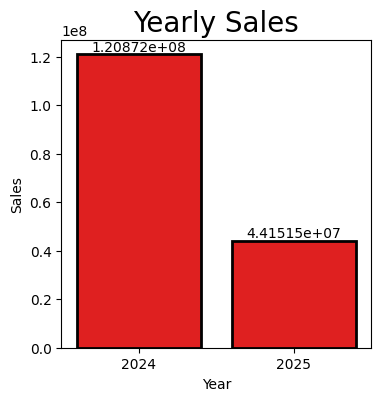

In [51]:
plt.figure(figsize=(4,4))
ax= sns.barplot(x='year',y='Sales',data=year,color="red",align = "edge",edgecolor = "black",linewidth = 2)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Yearly Sales',fontsize = 20)
plt.xlabel('Year')
plt.ylabel('Sales')

NOTE: Sales generate in year 2025 is lowest as compare to the previous year.

In [52]:
# Yearly Quantity Sold
year=df.groupby('year')['quantity'].sum()
year=pd.DataFrame(year.sort_values(ascending=False))
year

,quantity
year,
2024,2742
2025,943


Text(0, 0.5, 'Quantity')

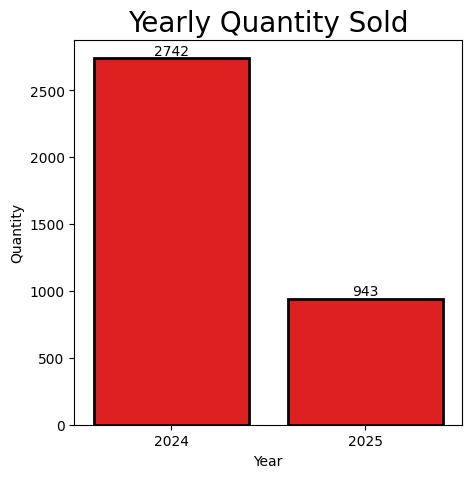

In [53]:
plt.figure(figsize=(5,5))
ax = sns.barplot(x='year',y='quantity',data=year,color="red",align = "edge",edgecolor = "black",linewidth = 2)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Yearly Quantity Sold',fontsize = 20)
plt.xlabel('Year')
plt.ylabel('Quantity')

NOTE: Quantity sold decreases in  year 2025 as compare to the previous year.
      

<Axes: xlabel='month', ylabel='Sales'>

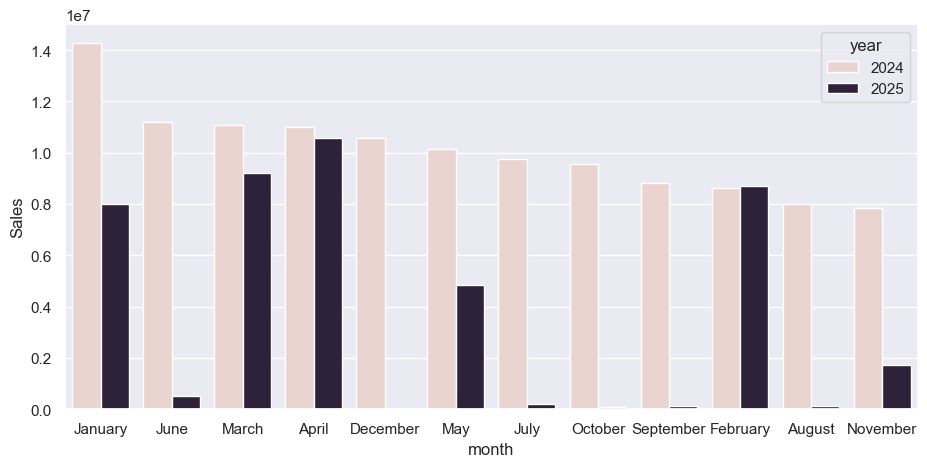

In [54]:
# Monthly and Yearly Trend
month_trend = df.groupby(["month", 'year'],as_index=False)["Sales"].sum().sort_values(by='Sales',ascending = False)

sns.set(rc={'figure.figsize':(11,5)})
sns.barplot(x='month',y='Sales', data = month_trend , hue='year')

NOTE: Year wise monthly sales:-
                       In 2025 Sales were good  during the first four months, but afterward the monthly sales started declining.

In [55]:
# Monthly Revenue 
monthly_sales = df.groupby('month')['Sales'].sum().astype('int')
print(monthly_sales.sort_values(ascending=False))

month
January      22296015
April        21569575
March        20284421
February     17330222
May          14990969
June         11699719
December     10593763
July          9962422
October       9663569
November      9550624
September     8952460
August        8129417
Name: Sales, dtype: int64


Text(0, 0.5, 'REVENUE')

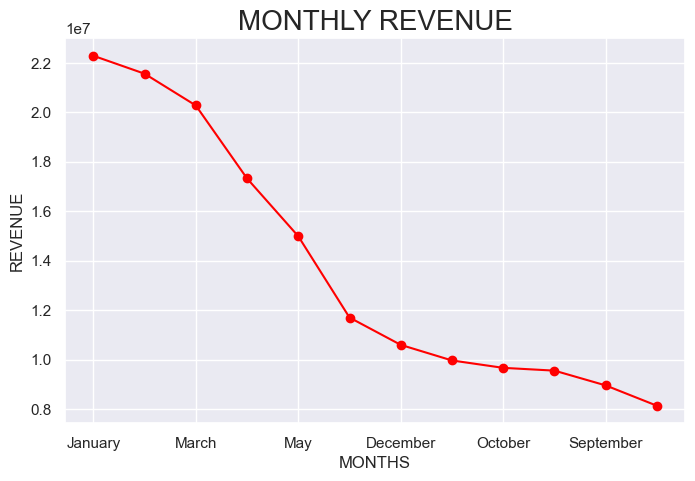

In [56]:
plt.figure(figsize=(8,5))
monthly_sales.sort_values(ascending=False).plot(kind='line',marker='o',color='red')
plt.title('MONTHLY REVENUE',fontsize = 20)
plt.xlabel('MONTHS')
plt.ylabel('REVENUE')

NOTE: Highest Revenue generated in January month.

In [57]:
# Monthly Quantity Sold
monthly_qty_sold = df.groupby('month')['quantity'].sum()
print(monthly_qty_sold.sort_values(ascending=False))

month
January      495
April        488
March        427
February     387
May          349
December     250
June         249
July         231
November     219
October      211
September    193
August       186
Name: quantity, dtype: int64


Text(0, 0.5, 'QUANTITY')

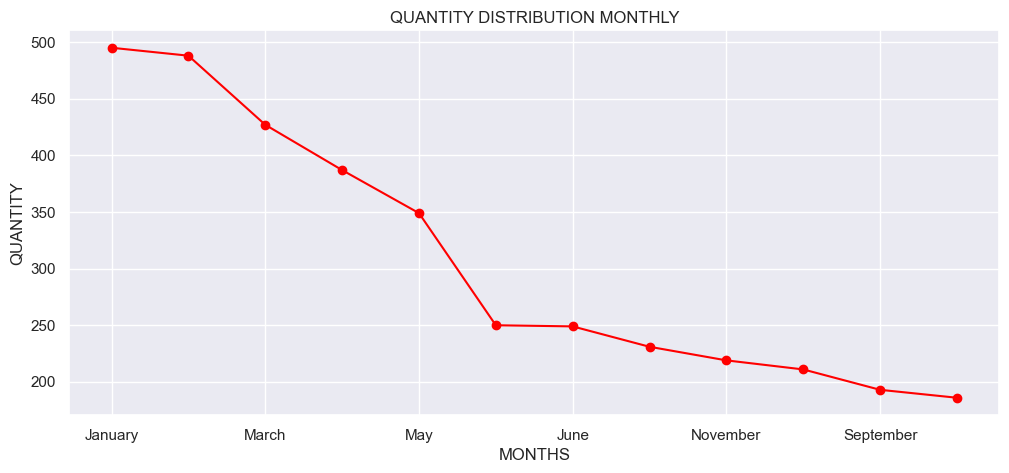

In [58]:
plt.figure(figsize=(12,5))
monthly_qty_sold.sort_values(ascending=False).plot(kind='line',marker='o',color='red')
plt.title('QUANTITY DISTRIBUTION MONTHLY')
plt.xlabel('MONTHS')
plt.ylabel('QUANTITY')

Note: Analyse that highest quantity sold in January month.

In [59]:
# Top_product by revenue
top_product = df.groupby('product_name')['Sales'].sum().head(7).astype('int')
top_5_prod = pd.DataFrame(top_product.sort_values(ascending=False))
top_5_prod

,Sales
product_name,
Dell Inspiron,17443441
Laptop Bag,17389637
Lenovo IdeaPad,11479789
Keyboard,8818222
Lenovo Tab,8503745
HP Pavilion,6206948
MacBook Air,1281157


Text(0, 0.5, 'REVENUE')

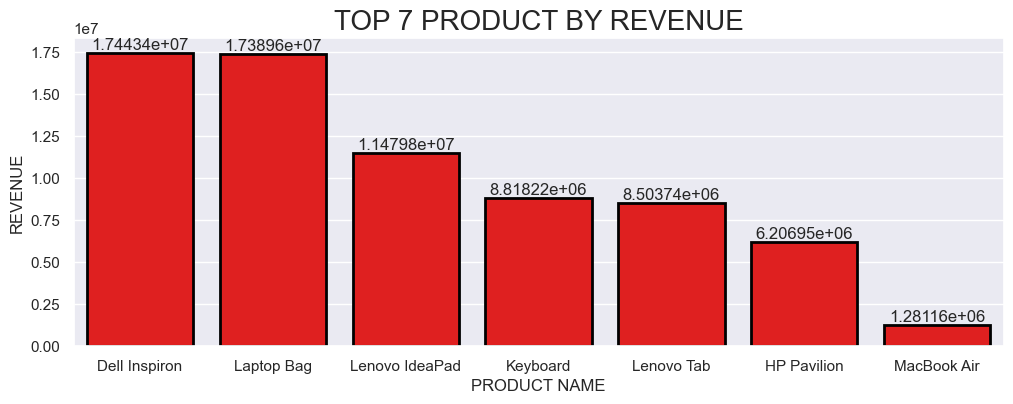

In [60]:
plt.figure(figsize=(12,4))
ax = sns.barplot(x='product_name',y='Sales',data=top_5_prod,color='red',align = "edge",edgecolor = "black",linewidth = 2)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('TOP 7 PRODUCT BY REVENUE',fontsize = 20)
plt.xlabel('PRODUCT NAME')
plt.ylabel('REVENUE')

NOTE: Dell Inspiron and Laptop Bag are two major selling product.

In [61]:
# Top product by quantity
top_product_sold = df.groupby('product_name')['quantity'].sum().head(7)
top_5_product = pd.DataFrame(top_product_sold.sort_values(ascending=False))
top_5_product

,quantity
product_name,
Dell Inspiron,361
Laptop Bag,354
Lenovo IdeaPad,262
Keyboard,205
Lenovo Tab,203
HP Pavilion,137
MacBook Air,31


Text(0, 0.5, 'QUANTITY')

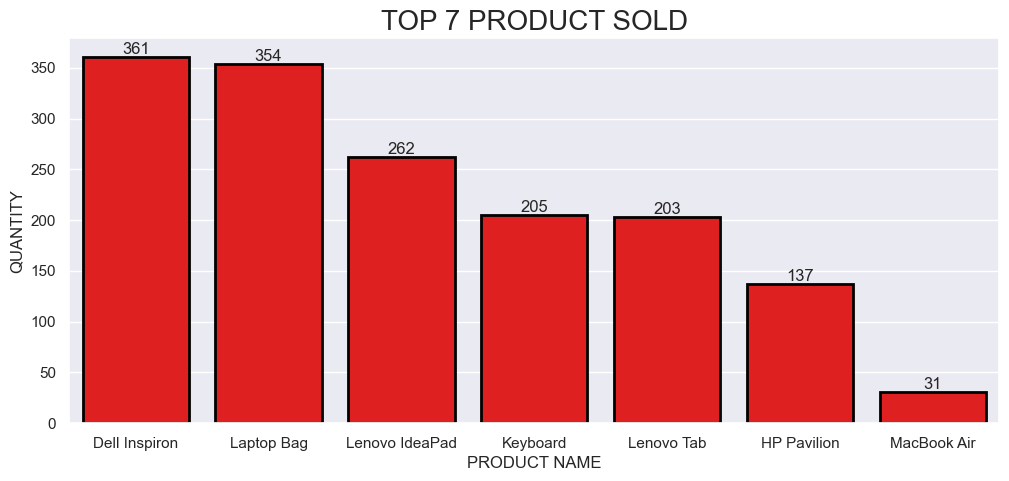

In [62]:
plt.figure(figsize=(12,5))
ax = sns.barplot(x='product_name',y='quantity',data=top_5_product,color='red',align = "edge",edgecolor = "black",linewidth = 2)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('TOP 7 PRODUCT SOLD',fontsize = 20)
plt.xlabel('PRODUCT NAME')
plt.ylabel('QUANTITY')

NOTE: Dell Inspiron and Laptop Bag are two highest sold product.

In [63]:
# Category Sales
category_revenue = df.groupby('category')['Sales'].sum().astype('int')
category_wise_revenue = pd.DataFrame(category_revenue.sort_values(ascending=False))
category_wise_revenue

,Sales
category,
Smartphone,53880121
Accessories,41561243
Tablet,38008154
Laptop,31573661


Text(0.5, 1.0, 'CATEGORY WISE REVENUE')

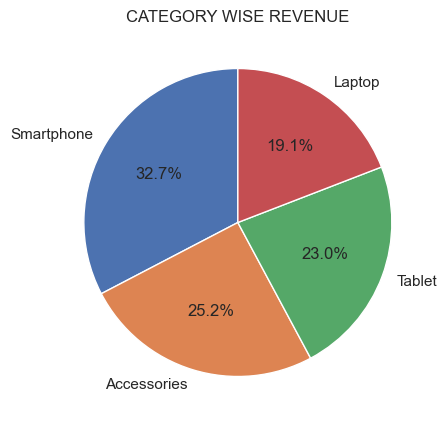

In [64]:
plt.pie(
    category_wise_revenue['Sales'],           # values
    labels=category_wise_revenue.index,        # category names
    autopct='%1.1f%%',                         # percentage show
    startangle=90
)
plt.title('CATEGORY WISE REVENUE')

NOTE: Smart phone genetrates highest revenue.

In [65]:
# Category Quantity Sold
category_qty = df.groupby('category')['quantity'].sum()
category_wise_qty = pd.DataFrame(category_qty.sort_values(ascending=False))
category_wise_qty

,quantity
category,
Smartphone,1187
Accessories,938
Tablet,852
Laptop,708


Text(0.5, 1.0, 'CATEGORY WISE QUANTITY SOLD')

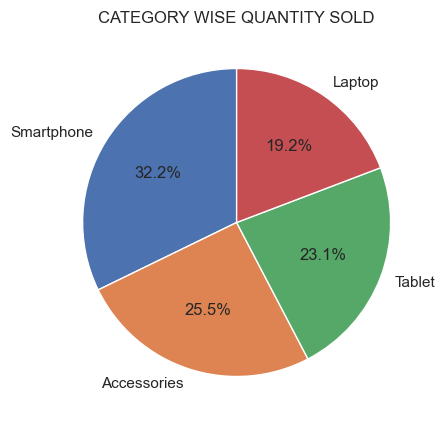

In [66]:
plt.pie(
    category_wise_qty['quantity'],           # values
    labels=category_wise_qty.index,        # category names
    autopct='%1.1f%%',                         # percentage show
    startangle=90
)
plt.title('CATEGORY WISE QUANTITY SOLD')

NOTE: Smart Phone are the highest selling product.

In [67]:
# City Sales
citywise_sales = df.groupby('city')['Sales'].sum().astype('int')
city_sales = pd.DataFrame(citywise_sales.sort_values(ascending=False))
city_sales

,Sales
city,
Delhi,49714139
Mumbai,27276319
Hyderabad,23631820
Bengaluru,23559824
Pune,17009852
Kolkata,12845589
Chennai,10985636


Text(0, 0.5, 'REVENUE')

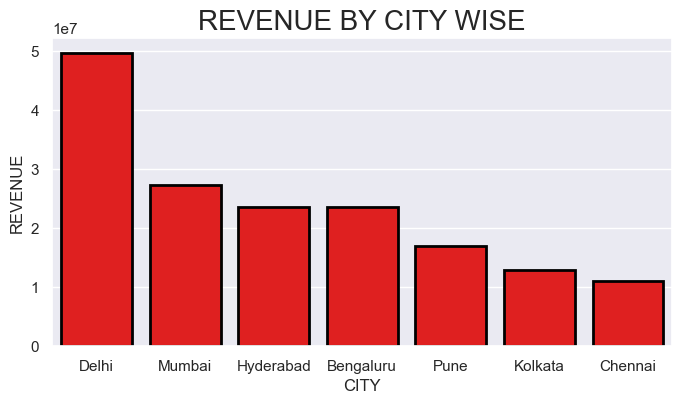

In [68]:
plt.figure(figsize=(8,4))
sns.barplot(x='city',y='Sales',data=city_sales,color='red',align = "edge",edgecolor = "black",linewidth = 2)
plt.title('REVENUE BY CITY WISE',fontsize = 20)
plt.xlabel('CITY')
plt.ylabel('REVENUE')

NOTE: Delhi generates the highest revenue.

In [69]:
# Quantity Sold In City 
citywise_qty = df.groupby('city')['quantity'].sum()
city_qty = pd.DataFrame(citywise_qty.sort_values(ascending=False))
city_qty

,quantity
city,
Delhi,1100
Mumbai,638
Bengaluru,550
Hyderabad,512
Pune,376
Kolkata,277
Chennai,232


Text(0, 0.5, 'QUANTITY')

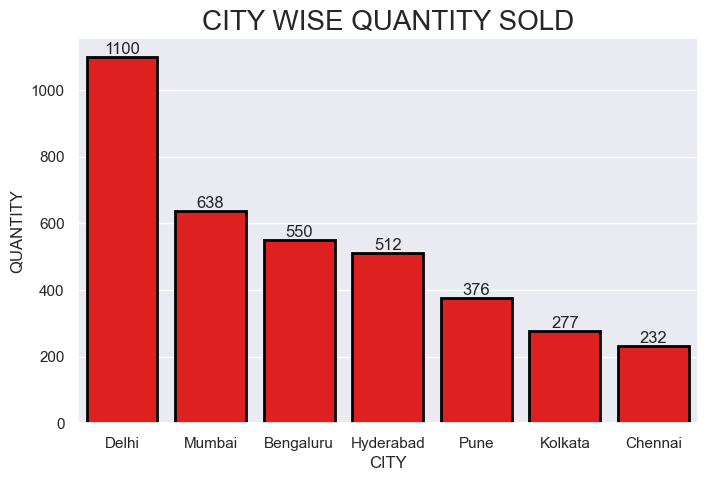

In [70]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x='city',y='quantity',data=city_qty,color='red',align = "edge",edgecolor = "black",linewidth = 2)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('CITY WISE QUANTITY SOLD',fontsize = 20)
plt.xlabel('CITY')
plt.ylabel('QUANTITY')

NOTE: Delhi has the highest quantity sold while Chennai has least quantity sold.

In [71]:
# Highest purchase by customer
top_customer = df.groupby('customer_id')['Sales'].sum().head(5).astype('int')
top_5_cust = pd.DataFrame(top_customer.sort_values(ascending=False))
top_5_cust

,Sales
customer_id,
C0001,1089958
C0005,890416
C0003,545229
C0002,494086
C0004,60996


Text(0, 0.5, 'REVENUE')

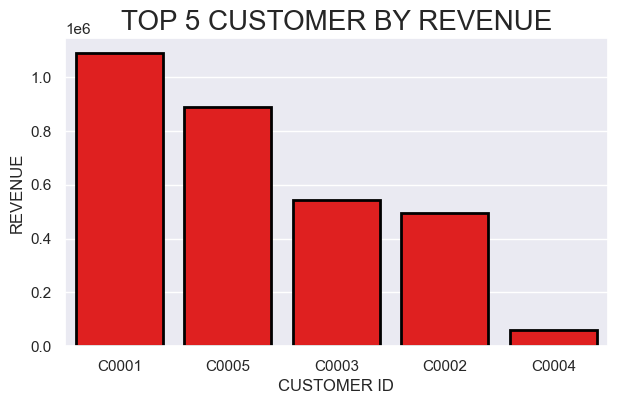

In [72]:
plt.figure(figsize=(7,4))
sns.barplot(x='customer_id',y='Sales',data=top_5_cust,color='red',align = "edge",edgecolor = "black",linewidth = 2)
plt.title('TOP 5 CUSTOMER BY REVENUE',fontsize = 20)
plt.xlabel('CUSTOMER ID')
plt.ylabel('REVENUE')

NOTE: Among the top five customers, C0001 recorded the highest revenue, making them the leading contributor.

In [73]:
# Highest Quantity of order by Customers
top_cust = df.groupby('customer_id')['quantity'].sum().head(5)
top_5_customer = pd.DataFrame(top_cust.sort_values(ascending=False))
top_5_customer

,quantity
customer_id,
C0001,21
C0005,20
C0003,11
C0002,9
C0004,4


Text(0, 0.5, 'QUANTITY')

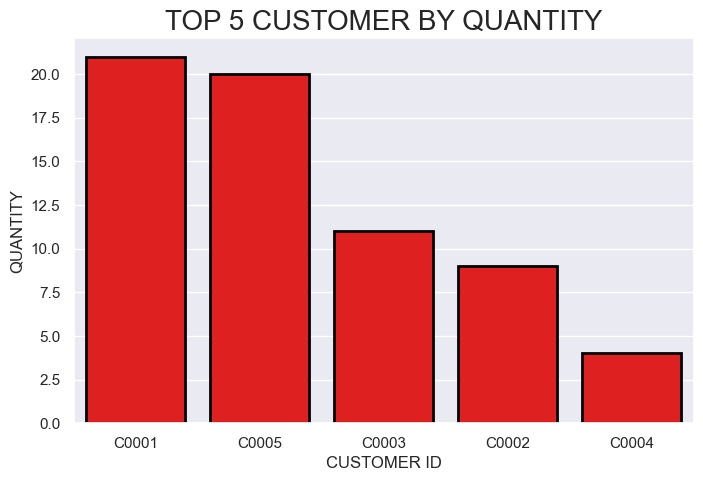

In [74]:
plt.figure(figsize=(8,5))
sns.barplot(x='customer_id',y='quantity',data=top_5_customer,color='red',align = "edge",edgecolor = "black",linewidth = 2)
plt.title('TOP 5 CUSTOMER BY QUANTITY',fontsize = 20)
plt.xlabel('CUSTOMER ID')
plt.ylabel('QUANTITY')

NOTE: Customer whose id is C0001, purchase most quantity of the product.

In [75]:
# Payment method 
payment_methods = df.groupby('payment_method')['Sales'].sum().astype('int')
payment_wise_revenue = pd.DataFrame(payment_methods.sort_values(ascending=False))
payment_wise_revenue

,Sales
payment_method,
Cash,49578475
Upi,47240103
Credit Card,46314821
Debit Card,21889780


Text(0.5, 1.0, 'PAYMENT METHOD DISTRIBUTION')

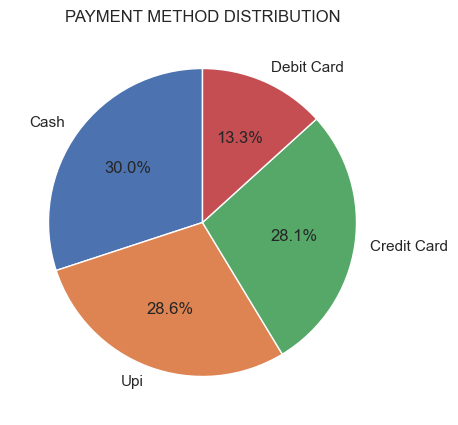

In [76]:
plt.pie(
    payment_wise_revenue['Sales'],           
    labels=payment_wise_revenue.index,        # category names
    autopct='%1.1f%%',                         # percentage show
    startangle=90
)
plt.title('PAYMENT METHOD DISTRIBUTION')

NOTE: Mostly payment received in cash.

In [77]:
# Payment Method Used
pay_methods = df.groupby('payment_method')['quantity'].sum()
pay = pd.DataFrame(pay_methods.sort_values(ascending=False))
pay

,quantity
payment_method,
Cash,1083
Credit Card,1066
Upi,1035
Debit Card,501


Text(0.5, 1.0, 'PAYMENT METHOD DISTRIBUTION')

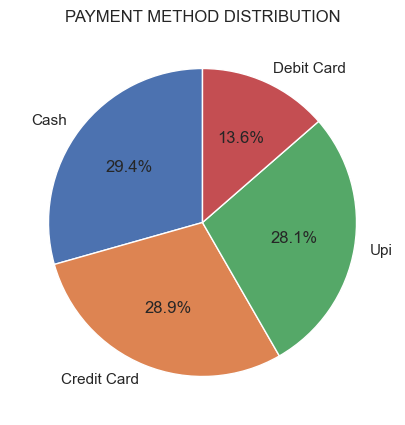

In [78]:
plt.pie(
    pay['quantity'],           # values
    labels=pay.index,        # category names
    autopct='%1.1f%%',         # percentage show karega
    startangle=90
)
plt.title('PAYMENT METHOD DISTRIBUTION')

NOTE:  Alomost 30% Quantity of product are sold in cash.

Text(0.5, 1.0, 'Correlation')

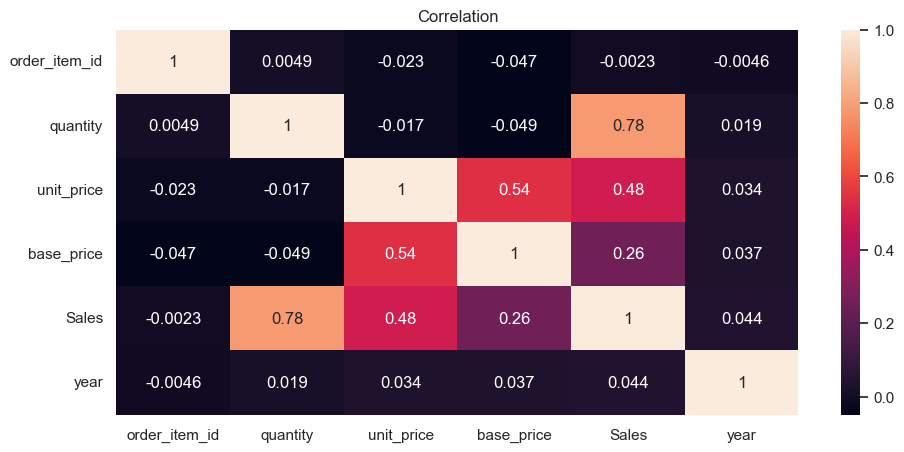

In [79]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True)
plt.title('Correlation')

NOTE: There is a strong correlation (0.78) between quantity and sales. As quantity increase sales also increase.

There is a moderate correlation (0.54) between base price and unit price. Since it is positive, when the base price increases, the unit price generally tends to increases too.

In [80]:
numeric_df.corr()

,order_item_id,quantity,unit_price,base_price,Sales,year
order_item_id,1.000000,0.004933,-0.023108,-0.047324,-0.002335,-0.004578
quantity,0.004933,1.000000,-0.016821,-0.048962,0.784052,0.018690
unit_price,-0.023108,-0.016821,1.000000,0.542167,0.483782,0.033557
base_price,-0.047324,-0.048962,0.542167,1.000000,0.255987,0.036631
Sales,-0.002335,0.784052,0.483782,0.255987,1.000000,0.043949
year,-0.004578,0.018690,0.033557,0.036631,0.043949,1.000000


# 8) CONCLUSION

SALES:--
      Total Sales/Revenue : ₹165023180
      Highest sales in yr : 2024 
      Highest Monthly sales : January
      Highest selling Product : Dell Inspiron and Laptop Bag are two major selling product
      Highest selling category :  Smart phone
      Least selling category : Laptop 
      Highest sales in city : Delhi 
      Least sales in city : Chennai
      Highest purchase by customer_id :  C0001
      Mosthly payment recived in : Cash
      Least payment method used : Debit card
      Customers C0001 and C0005 are identified as the company’s key customers because of their significant contribution to overall sales and revenue.


Quantity:--
     Total Quantity sold : 3685
     Highest Quantity sold in yr : 2024 
     Top sold Product : Dell Inspiron and Laptop Bag are two major sold product
     Top Quantity sold category :  Smart phone
     Least Quantity sold category : Laptop 


Statistical Analysis:
      Correlation Heatmap: strong correlation (0.78) between quantity and sales, relation between numerical variables.
            